# Training the Base House-Price Regression Model

Every attack and defense notebook in this repo targets a single model: a small feedforward network trained to predict median house value from 8 numeric features of the California Housing dataset (Pace & Barry, 1997, the standard modern replacement for the ethically-retired Boston Housing dataset). This is the tabular equivalent of TrafficNet in the vision repo or the keyword spotter in the audio repo: a compact, from-scratch-trained model rather than a large pretrained one, so the full attack pipeline stays simple and fast to iterate on.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

### Setup: Dataset
8 features describing a California census block group (income, age, room/bedroom counts, population, occupancy, location) predicting `MedHouseVal`, the median house value in units of $100,000. `fetch_california_housing` downloads and caches the dataset the first time it runs; no local copy is tracked in this repo.

In [2]:
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target  # MedHouseVal, in $100,000s

FEATURE_NAMES = list(X.columns)
print(f"{len(X)} rows, {len(FEATURE_NAMES)} features: {FEATURE_NAMES}")
print(f"Target range: ${y.min() * 100_000:,.0f} - ${y.max() * 100_000:,.0f}, mean ${y.mean() * 100_000:,.0f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32)
print(f"Train: {len(X_train_t)}, Test: {len(X_test_t)}")

20640 rows, 8 features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target range: $14,999 - $500,001, mean $206,856
Train: 16512, Test: 4128


### Setup: Model
A small 3-layer MLP over the 8 standardized features. Standardization matters here in a way it does not for images: the 8 features are on completely different scales (income in tens of thousands, room counts in single digits, population in thousands), so an unstandardized network would implicitly treat a change of "1" in each feature as equally significant, which is not true and would also break the epsilon-based attacks in `attacks/`, where a single epsilon is meant to apply fairly across features.

In [3]:
class HousePriceNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = HousePriceNet(n_features=len(FEATURE_NAMES))
print(model)

HousePriceNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Training
Plain supervised regression: mean squared error, Adam, a few hundred epochs since the dataset is
small (~16,500 training rows) and the model is tiny.

Epoch 50/300 - train MSE: 1.4484


Epoch 100/300 - train MSE: 0.7051


Epoch 150/300 - train MSE: 0.5494


Epoch 200/300 - train MSE: 0.4582


Epoch 250/300 - train MSE: 0.4163


Epoch 300/300 - train MSE: 0.3914


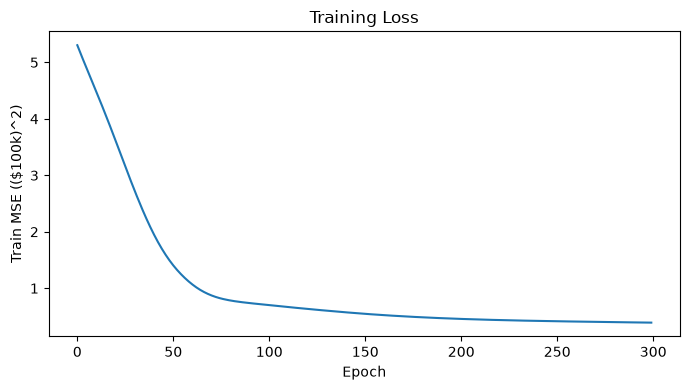

In [4]:
EPOCHS = 300
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

history = []
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train_t)
    loss = loss_fn(preds, y_train_t)
    loss.backward()
    optimizer.step()
    history.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS} - train MSE: {loss.item():.4f}")

plt.figure(figsize=(7, 4))
plt.plot(history)
plt.xlabel('Epoch')
plt.ylabel('Train MSE (($100k)^2)')
plt.title('Training Loss')
plt.tight_layout()
plt.show()

### Test Accuracy and Saving
The saved weights (`models/house_price_net.pth`) and the fitted `StandardScaler`'s parameters (saved
alongside, since every attack notebook needs to standardize new inputs the same way) are the target
for every attack and defense notebook in this repo.

In [5]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).numpy()

test_mse = mean_squared_error(y_test_t.numpy(), test_preds)
test_rmse_dollars = np.sqrt(test_mse) * 100_000
test_r2 = r2_score(y_test_t.numpy(), test_preds)
print(f"Test MSE: {test_mse:.4f} (in ($100k)^2)")
print(f"Test RMSE: ${test_rmse_dollars:,.0f}")
print(f"Test R^2: {test_r2:.3f}")

torch.save({
    'model_state_dict': model.state_dict(),
    'feature_names': FEATURE_NAMES,
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
}, 'house_price_net.pth')
print("Saved models/house_price_net.pth")

Test MSE: 0.4004 (in ($100k)^2)
Test RMSE: $63,278
Test R^2: 0.694
Saved models/house_price_net.pth
